# Download and Preview Market Data

This notebook runs the first stage of the project: download raw equity history and option-chain data from Yahoo Finance, save the raw CSV files, and inspect the returned tables.

In [2]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd if (cwd / "src" / "bs_pricer").exists() else cwd.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from bs_pricer.config import MarketConfig
from bs_pricer.pipeline import run_pipeline

PROJECT_ROOT

PosixPath('/Users/Brett_Xu/Documents/Option-pricer')

In [3]:
config = MarketConfig(
    ticker="SPY",
    start_date="2023-01-01",
    end_date=None,
)

config

MarketConfig(ticker='SPY', start_date='2023-01-01', end_date=None, risk_free_rate=0.05, dividend_yield=0.0, trading_days_per_year=252, raw_data_dir=PosixPath('data/raw'), processed_data_dir=PosixPath('data/processed'))

## Volatility Comparison Setup

For SPY, this notebook downloads equity history from 2023-01-01 onward. Later, realized volatility can be compared with option maturity buckets using common trading-day windows: 21 days for roughly 1 month, 63 days for roughly 3 months, and 126 days for roughly 6 months.

In [4]:
result = run_pipeline(config)

equity_history = result["equity_history"]
option_chains = result["option_chains"]
equity_clean = result["equity_clean"]
options_clean = result["options_clean"]

result["equity_path"], result["options_path"], result["equity_processed_path"], result["options_processed_path"]

(PosixPath('data/raw/SPY_equity_history.csv'),
 PosixPath('data/raw/SPY_option_chains.csv'))

In [5]:
equity_history.shape, option_chains.shape

((843, 9), (9286, 16))

In [6]:
equity_history.head()

,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,,
2023-01-03 00:00:00-05:00,384.369995,386.429993,377.829987,380.820007,365.072052,74850700,0.0,0.0,0.0
2023-01-04 00:00:00-05:00,383.179993,385.880005,380.000000,383.760010,367.890503,85934100,0.0,0.0,0.0
2023-01-05 00:00:00-05:00,381.720001,381.839996,378.760010,379.380005,363.691559,76970500,0.0,0.0,0.0
2023-01-06 00:00:00-05:00,382.609985,389.250000,379.410004,388.079987,372.031769,104189600,0.0,0.0,0.0
2023-01-09 00:00:00-05:00,390.369995,393.700012,387.670013,387.859985,371.820923,73978100,0.0,0.0,0.0


Text(0, 0.5, 'Price')

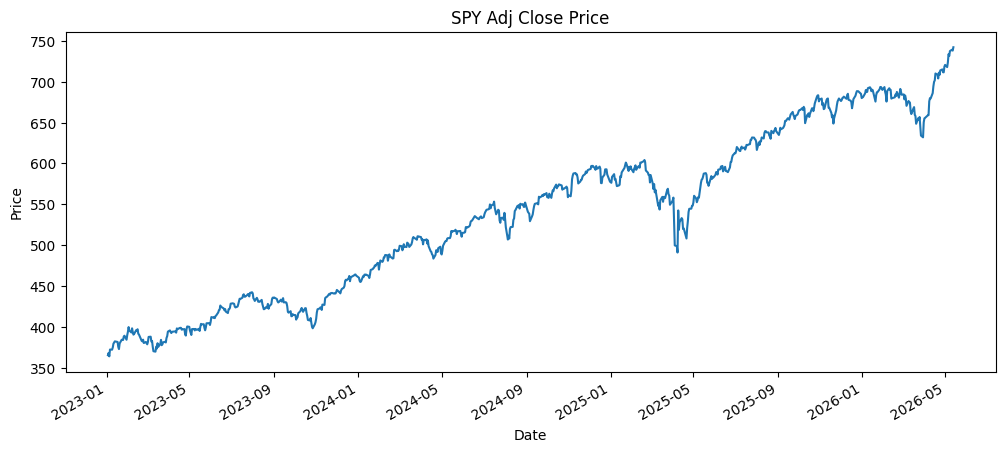

In [7]:
price_col = "Adj Close" if "Adj Close" in equity_history.columns else "Close"

ax = equity_history[price_col].plot(
    figsize=(12, 5),
    title=f"{config.ticker} {price_col} Price",
)
ax.set_xlabel("Date")
ax.set_ylabel("Price")

In [ ]:
equity_history.tail()

In [ ]:
option_chains.head()

In [ ]:
option_chains.columns.tolist()

In [ ]:
option_chains.groupby(["expiry", "option_type"]).size().head(20)

In [ ]:
option_chains[["contractSymbol", "expiry", "option_type", "strike", "lastPrice", "bid", "ask", "volume", "openInterest", "impliedVolatility"]].head(20)

## Cleaned Data Preview

In [ ]:
equity_clean.head()

In [ ]:
options_clean.head()

In [ ]:
options_clean[["option_type", "expiry", "strike", "mid_price", "spot", "moneyness", "days_to_expiry", "time_to_expiry"]].head(20)